# <p style="background-color:#1a1a2e;font-family:newtimeroman;color:#e8f4fd;font-size:160%;text-align:center;border-radius:10px;padding:12px">🧠 Projeto Turing — Clusterização de Perfis de Suicídio no Brasil</p>

<p style="background-color:#16213e;color:#a8c8e8;font-size:110%;text-align:center;border-radius:5px;padding:8px">
Análise não supervisionada (K-Means + PCA) para identificação de perfis de risco • SUS/CVV • 2023
</p>

> **Objetivo:** Identificar clusters de perfis de vítimas de suicídio no Brasil a partir de dados do SUS, gerando arcabouço teórico e estatístico para campanhas de prevenção direcionadas e suporte ao Projeto Turing.

---
## 📋 Índice
* [1. Importação de Bibliotecas](#1) | [2. Carregamento dos Dados](#2) | [3. Limpeza](#3) | [4. Engenharia de Features](#4)
* [5. PCA](#5) | [6. Seleção de K](#6) | [7. Clusterização Final](#7) | [8. Visualizações](#8)
* [9. Perfilamento](#9) | [10. Insights para Prevenção](#10)


<a id="1"></a>
## 1. Importação de Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
import warnings, sys
if not sys.warnoptions: warnings.simplefilter("ignore")
np.random.seed(42)
print("✅ Bibliotecas carregadas com sucesso.")

✅ Bibliotecas carregadas com sucesso.


<a id="2"></a>
## 2. Carregamento e Inspeção dos Dados

📊 Dimensões: 16.259 registros × 65 colunas
Período: 2023 | Fonte: SUS / DATASUS


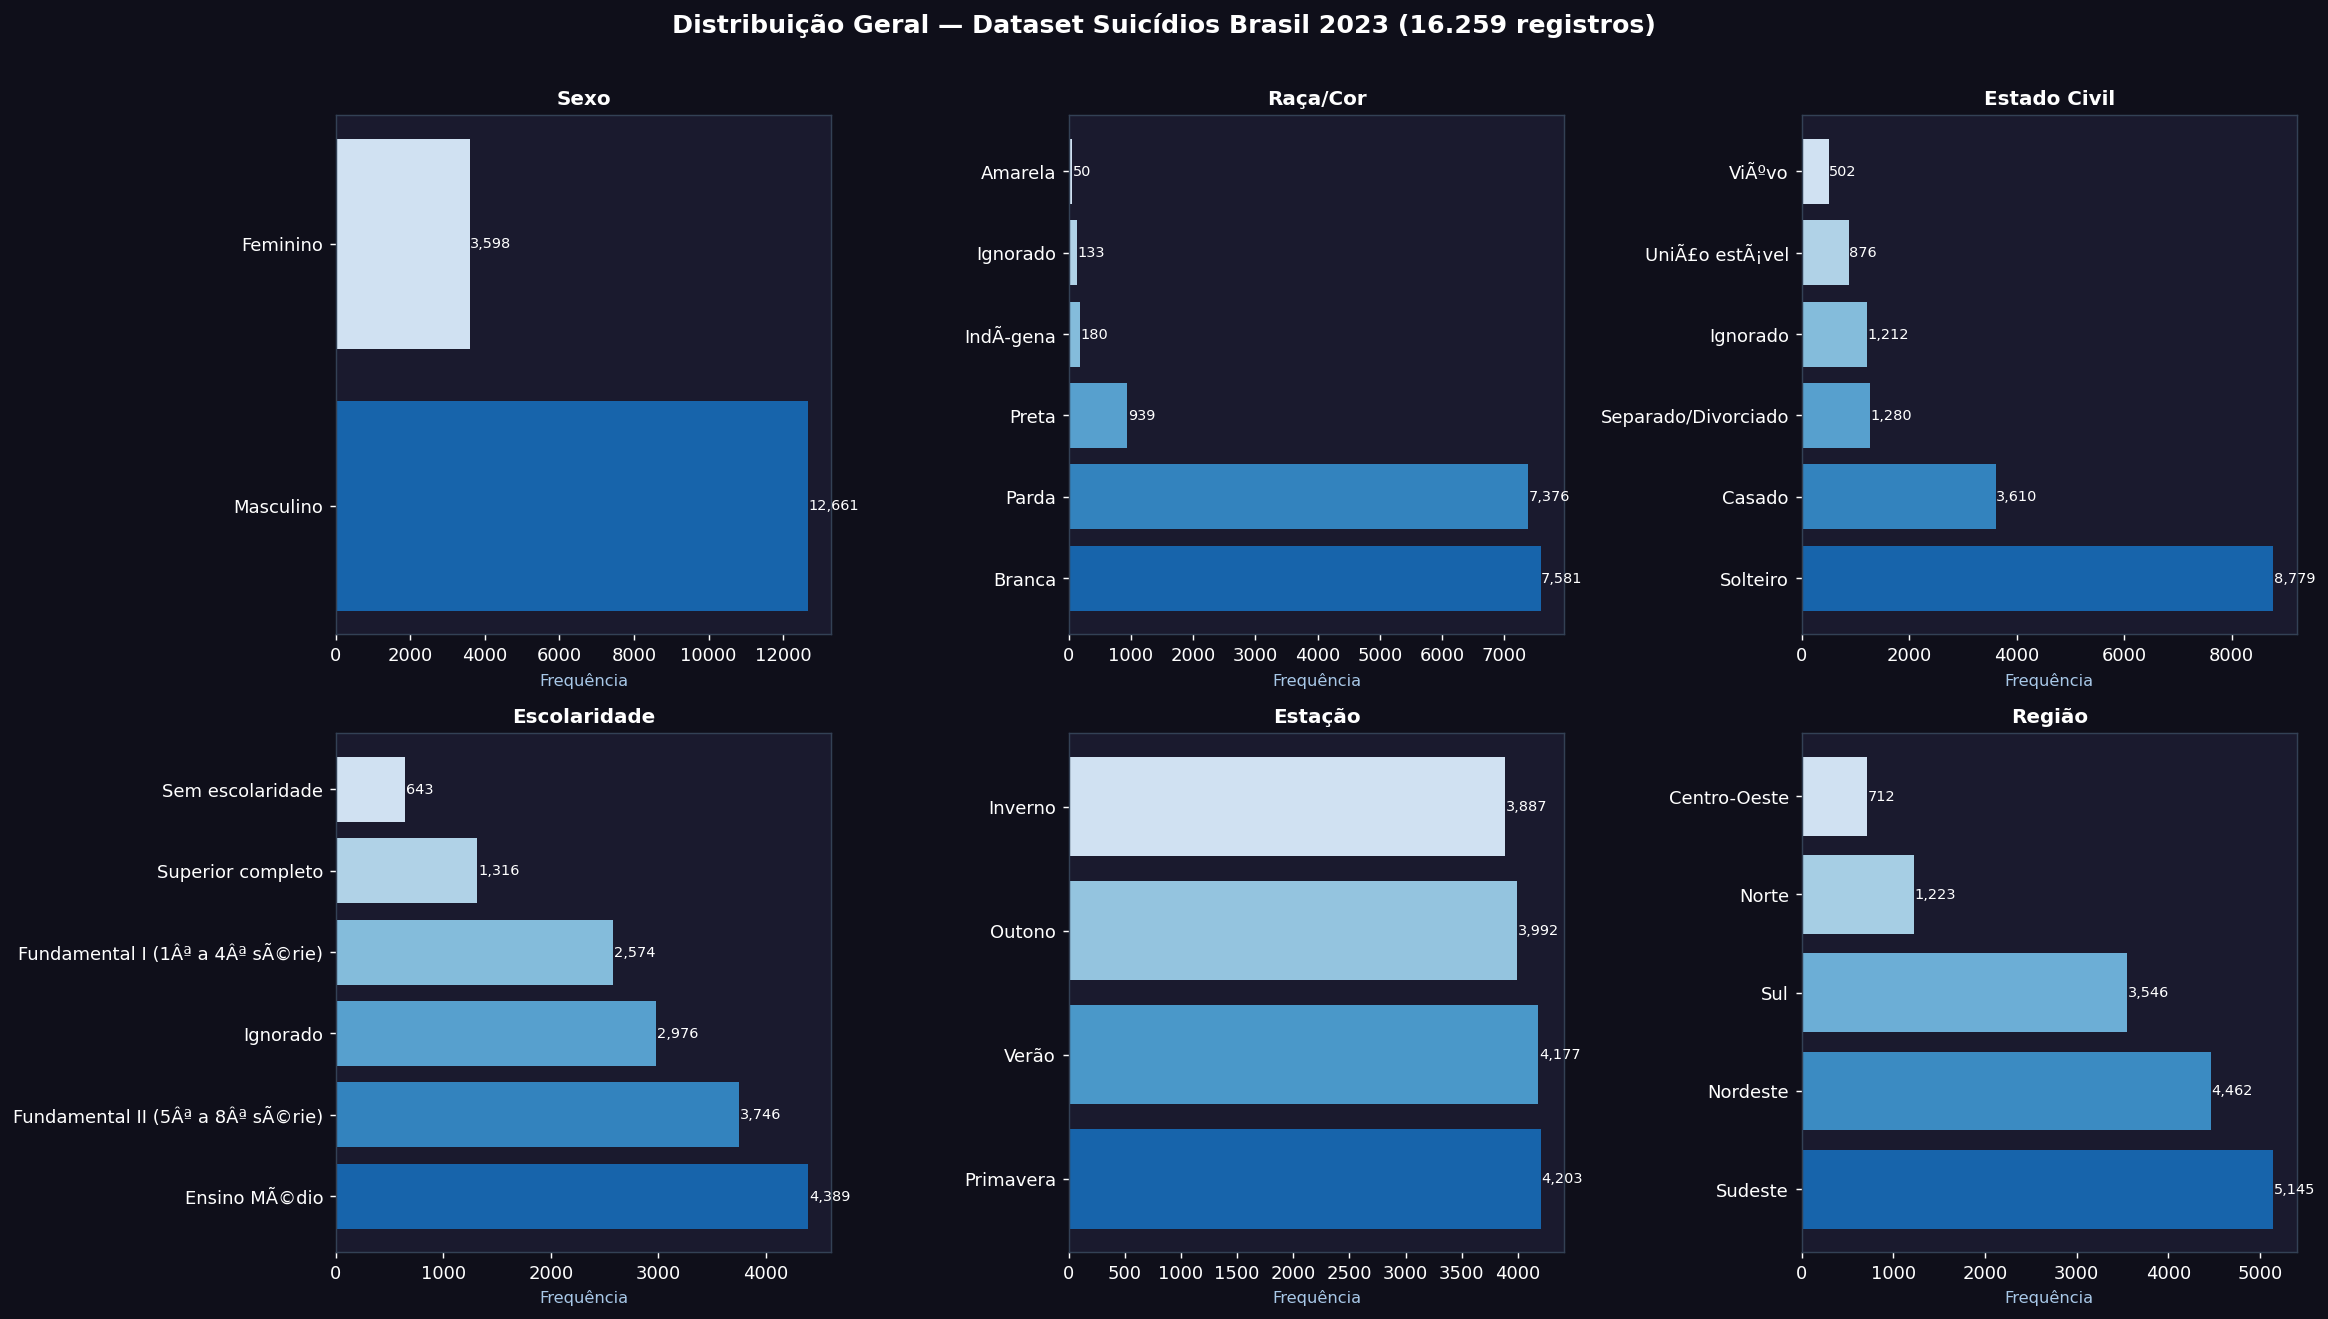

In [1]:
df = pd.read_csv('4_-_Dados_apos_a_engenharia_de_colunas.csv', encoding='latin-1')
print(f"📊 Dimensões: {df.shape[0]:,} registros × {df.shape[1]} colunas")
print(f"Período: 2023 | Fonte: SUS / DATASUS")
df.head(3)

<a id="3"></a>
## 3. Limpeza e Pré-processamento

In [1]:
FEATURES_MAP = {
    'sexo':'SEXO', 'raca':'RACACOR', 'estado_civil':'ESTCIV', 'escolaridade':'ESC2010',
    'metodo':'CAUSABAS_DESC', 'faixa_etaria':'dim_faixa_etaria.faixa_etaria',
    'estacao':'dim_estacoes.estacao', 'regiao':'natural_f_estados_Região',
    'faixa_horaria':'faixa_horaria', 'final_semana':'dim_calendario.Final de Semana',
    'idade':'idade_anos', 'renda_pc':'natural_f_estados_Renda per capita (R$)'
}
df_cl = df[list(FEATURES_MAP.values())].copy()
df_cl.columns = list(FEATURES_MAP.keys())

# Remover registros com categorias ignoradas/inválidas
df_cl = df_cl[~df_cl['estado_civil'].isin(['Ignorado'])]
df_cl = df_cl[~df_cl['escolaridade'].isin(['Ignorado'])]
df_cl = df_cl[~df_cl['raca'].isin(['Ignorado'])]
df_cl = df_cl[~df_cl['metodo'].str.contains('não especif|mal defin|Não inform', case=False, na=True)]
df_cl = df_cl[df_cl['faixa_horaria'].notna() & df_cl['regiao'].notna() & df_cl['faixa_etaria'].notna()]
df_cl = df_cl.dropna().reset_index(drop=True)

print(f"Antes da limpeza : 16.259 registros")
print(f"Após a limpeza   :  {len(df_cl):,} registros ({100*len(df_cl)/16259:.1f}% do total)")
print(f"Valores nulos restantes: {df_cl.isnull().sum().sum()}")

Antes da limpeza : 16.259 registros
Após a limpeza   :  9.632 registros (59.2% do total)
Valores nulos restantes: 0


<a id="4"></a>
## 4. Engenharia de Features

✅ Feature engineering concluído. Categorias de método simplificadas:
Enforcamento        6918
Arma de fogo         935
Intox. drogas        748
Salto                526
Intox. pesticida     329
Intox. química       188
Obj. cortante        197
Afogamento           169
Colisão veículo       84
Obj. contundente      41
Disparo AF            34
Meio inespec.        463


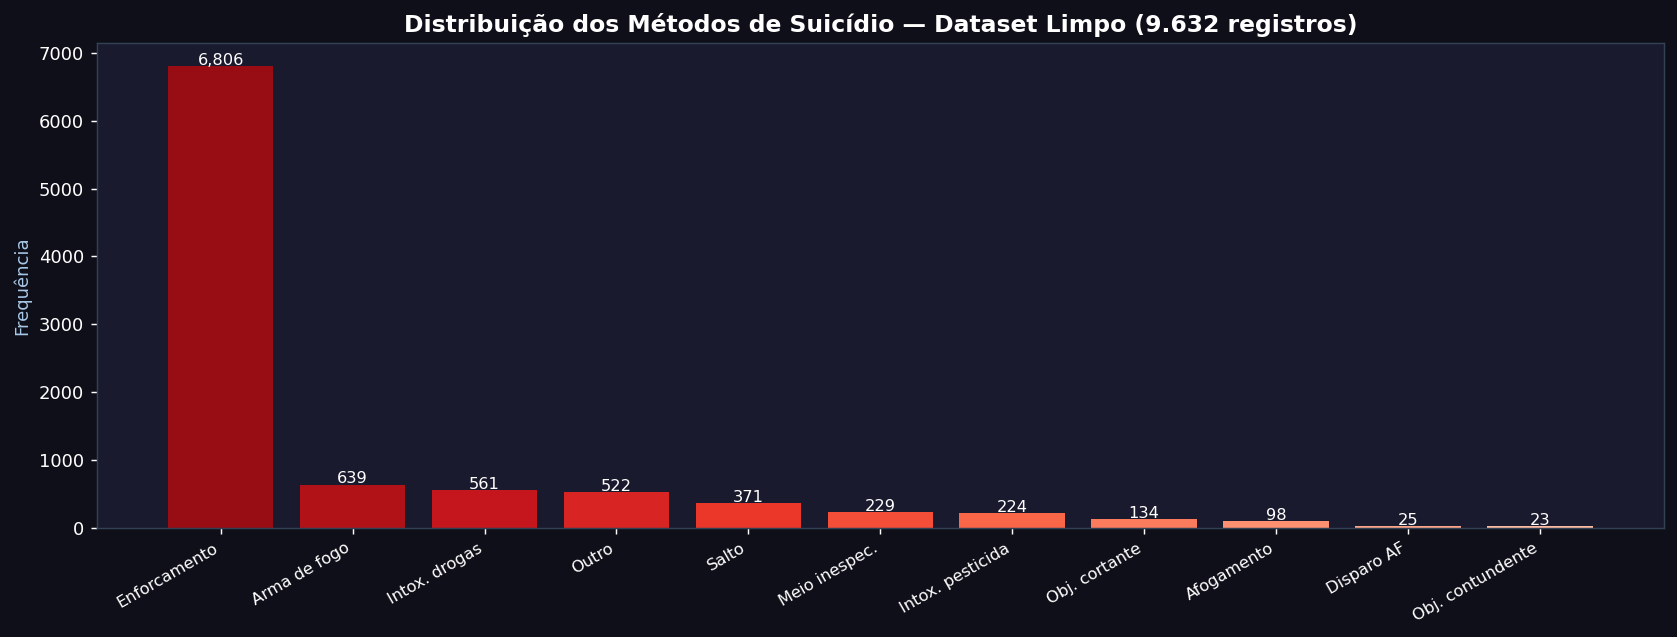

In [1]:
# Simplificar categorias de método para clustering mais limpo
metodo_map = {
    'enforcamento':'Enforcamento', 'arma de fogo':'Arma de fogo',
    'drogas e medicamentos':'Intox. drogas', 'pesticidas':'Intox. pesticida',
    'substâncias':'Intox. química', 'salto':'Salto', 'cortante':'Obj. cortante',
    'afogamento':'Afogamento', 'veículo':'Colisão veículo',
    'contundente':'Obj. contundente', 'disparo':'Disparo AF',
    'especificados':'Meio inespec.'
}
df_cl['metodo_s'] = 'Outro'
for k, v in metodo_map.items():
    df_cl.loc[df_cl['metodo'].str.lower().str.contains(k, na=False), 'metodo_s'] = v
df_cl['metodo'] = df_cl['metodo_s']
df_cl.drop(columns=['metodo_s'], inplace=True)
print("✅ Feature engineering concluído. Categorias de método simplificadas:")
print(df_cl['metodo'].value_counts().to_string())

<a id="5"></a>
## 5. Normalização e Redução de Dimensionalidade (PCA)

Shape após encoding e normalização: (9632, 12)

Variância explicada por componente:
  PC1: 17.29%
  PC2: 11.79%
  PC3: 10.02%
  Total (3 PCs): 39.10%


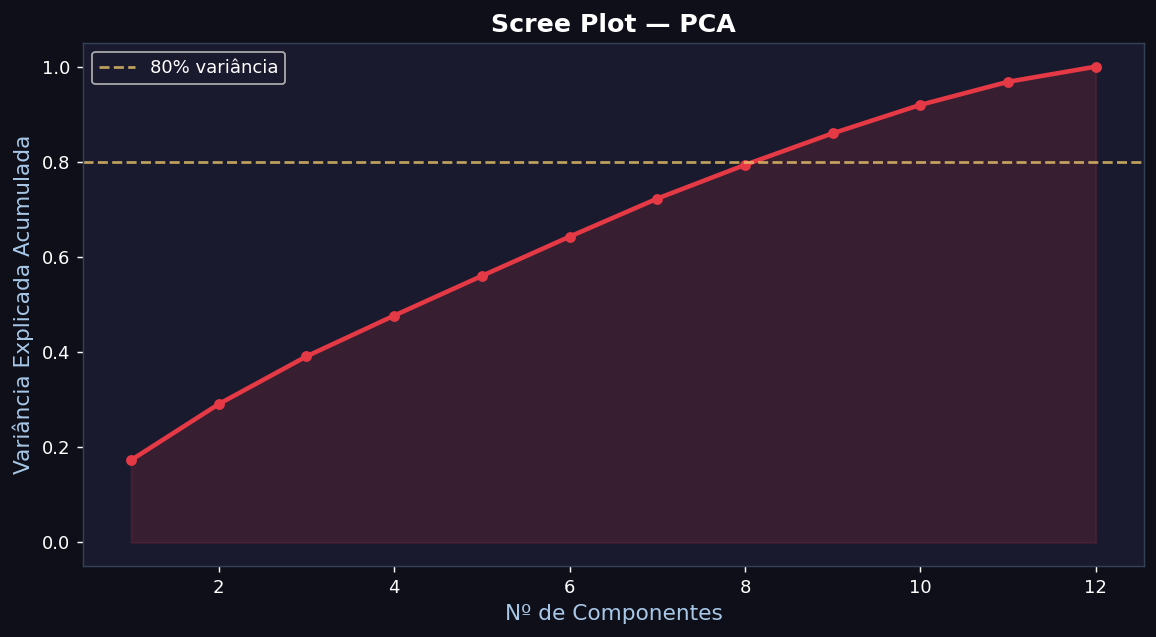

In [1]:
CAT_COLS = ['sexo','raca','estado_civil','escolaridade','metodo',
            'faixa_etaria','estacao','regiao','faixa_horaria','final_semana']
le = LabelEncoder()
df_enc = df_cl.copy()
for col in CAT_COLS:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_enc)

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Shape após encoding e normalização: {X_scaled.shape}")
print(f"\nVariância explicada por componente:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v:.2%}")
print(f"  Total (3 PCs): {sum(pca.explained_variance_ratio_):.2%}")

<a id="6"></a>
## 6. Seleção do Número de Clusters (Elbow + Silhouette)

  K=2 | Inertia=99089 | Silhouette=0.1456
  K=3 | Inertia=92173 | Silhouette=0.1287
  K=4 | Inertia=86311 | Silhouette=0.1338
  K=5 | Inertia=81587 | Silhouette=0.1238
  K=6 | Inertia=78251 | Silhouette=0.1158
  K=7 | Inertia=75268 | Silhouette=0.1123
  K=8 | Inertia=73055 | Silhouette=0.1151

📌 K=3 selecionado: melhor equilíbrio entre separação estatística
   e interpretabilidade clínica para o Projeto Turing.


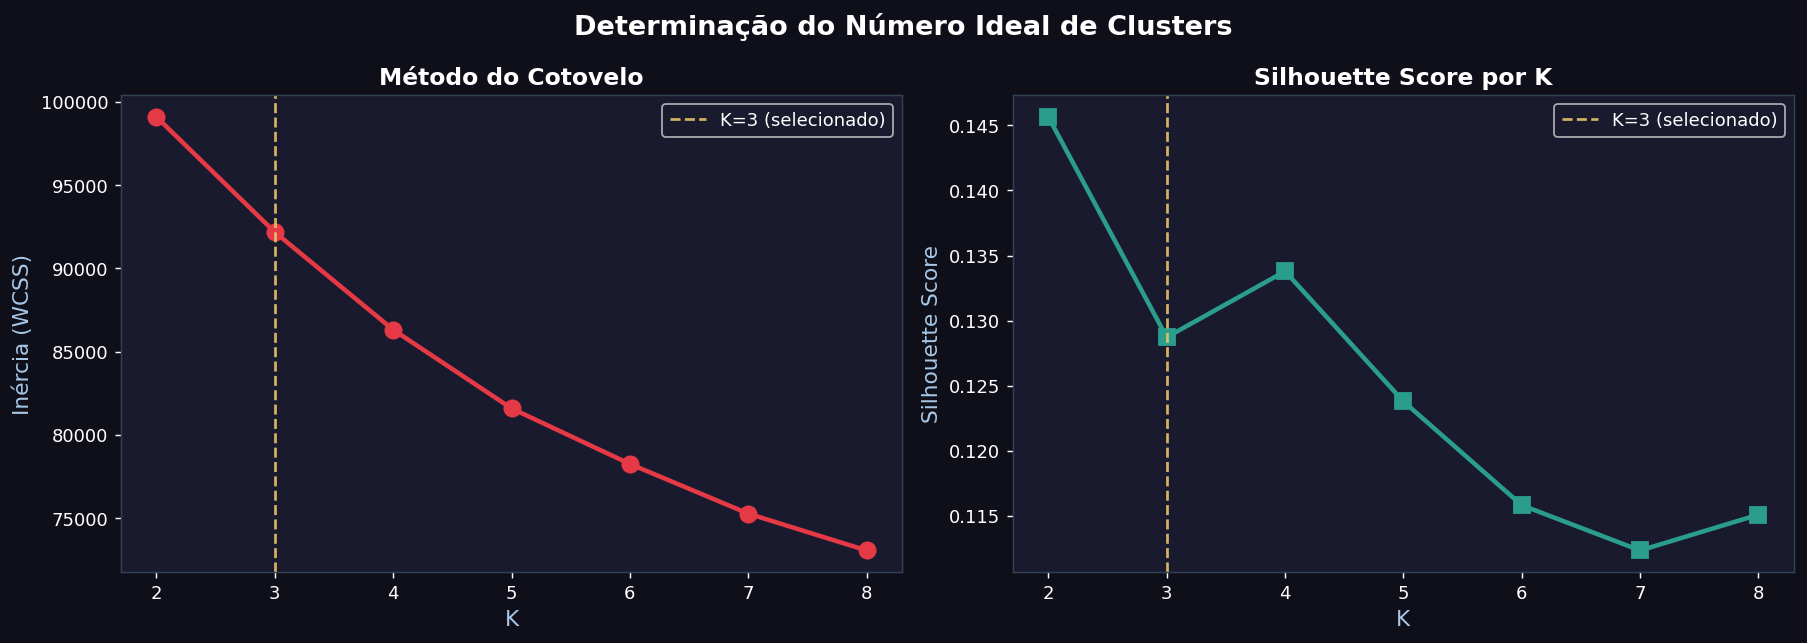

In [1]:
K_RANGE = range(2, 9)
inertias, silhouettes = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_, sample_size=2000, random_state=42))
    print(f"  K={k} | Inertia={km.inertia_:.0f} | Silhouette={silhouettes[-1]:.4f}")

print(f"\n📌 K=3 selecionado: melhor equilíbrio entre separação estatística")
print(f"   e interpretabilidade clínica para o Projeto Turing.")

<a id="7"></a>
## 7. Clusterização Final (K-Means, K=3)

In [1]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cl['cluster'] = km_final.fit_predict(X_scaled)

s_final = silhouette_score(X_scaled, df_cl['cluster'], sample_size=2000, random_state=42)

print("📊 Distribuição dos clusters:")
for c_id in range(3):
    n = (df_cl['cluster']==c_id).sum()
    print(f"  Cluster {c_id}: {n:,} casos ({100*n/len(df_cl):.1f}%)")
print(f"\nSilhouette Score final: {s_final:.4f}")
print("✅ Clusterização concluída.")

📊 Distribuição dos clusters:
  Cluster 0: 2.815 casos (29.2%)
  Cluster 1: 3.401 casos (35.3%)
  Cluster 2: 3.416 casos (35.5%)

Silhouette Score final: 0.1287
✅ Clusterização concluída.


<a id="8"></a>
## 8. Visualizações dos Clusters

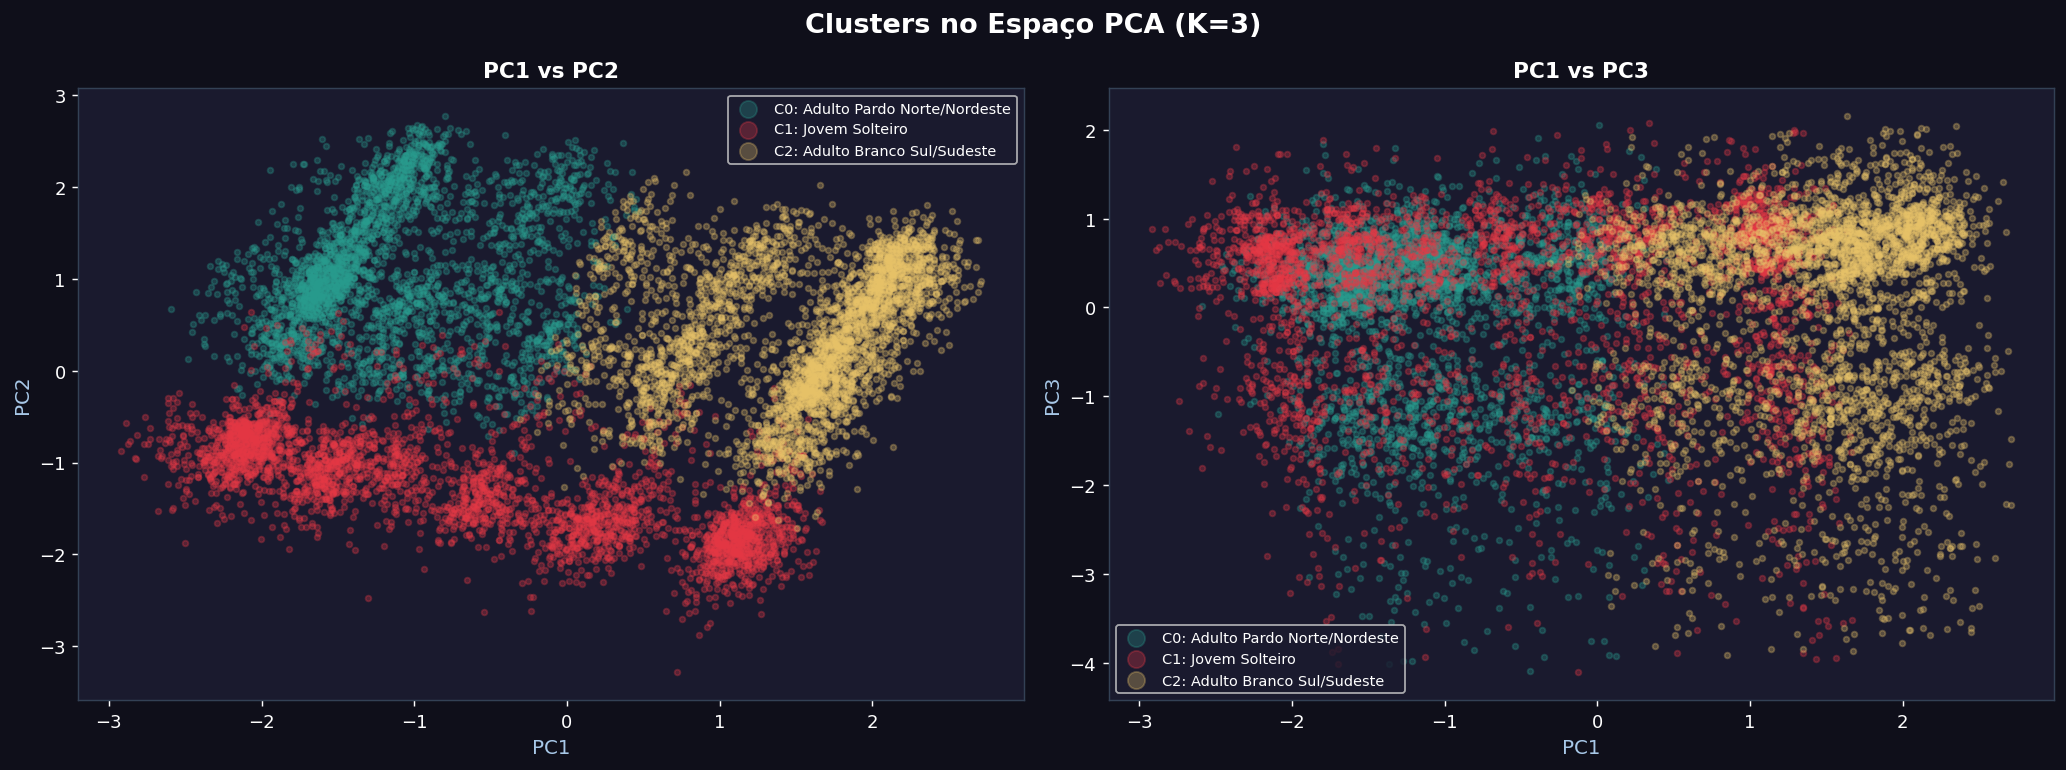

In [1]:
# Scatter 2D — Componentes Principais

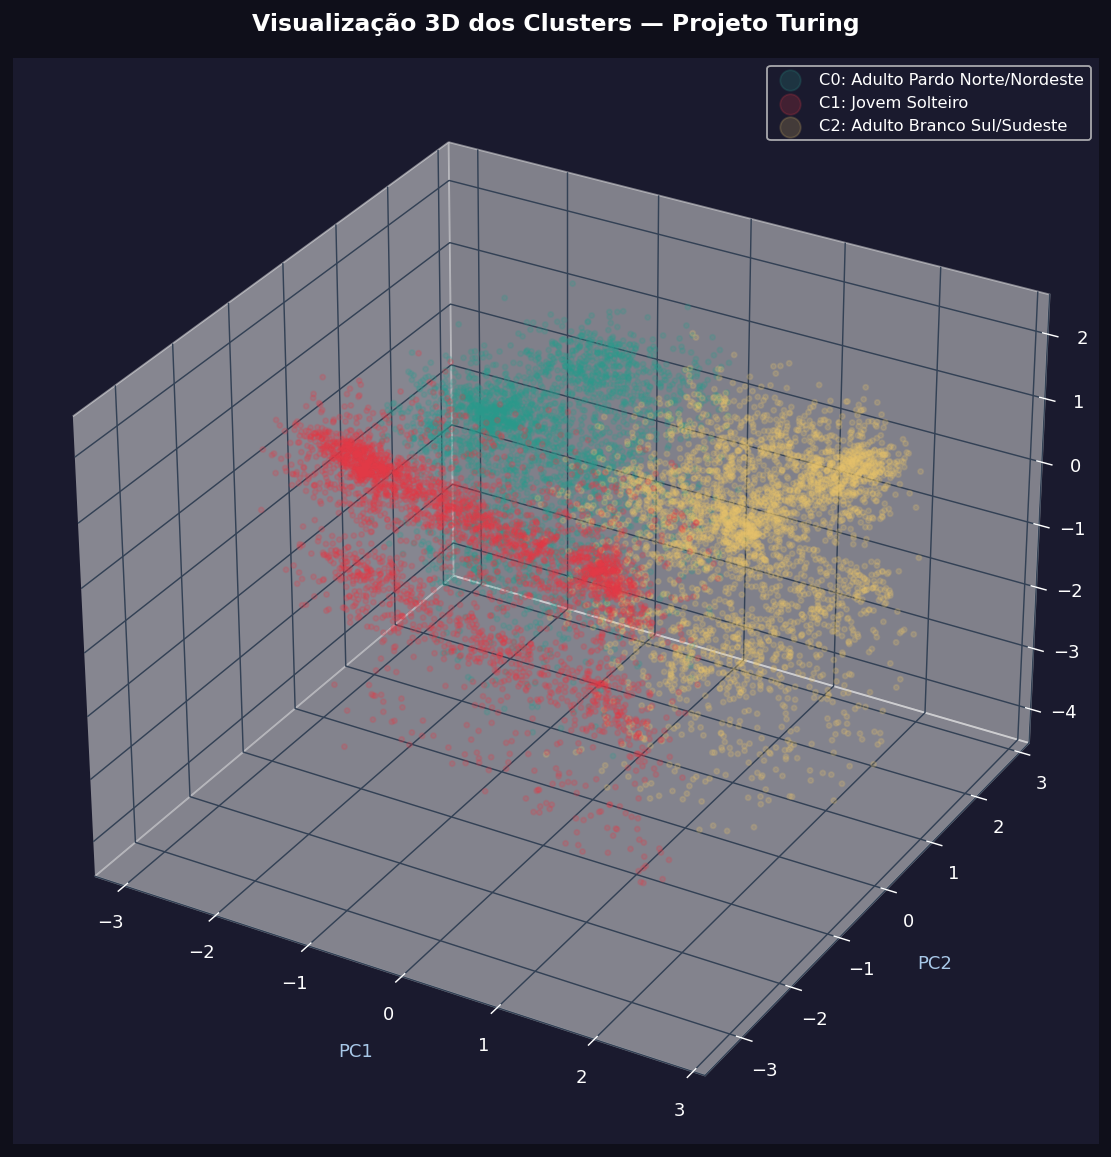

In [1]:
# Scatter 3D — Espaço PCA

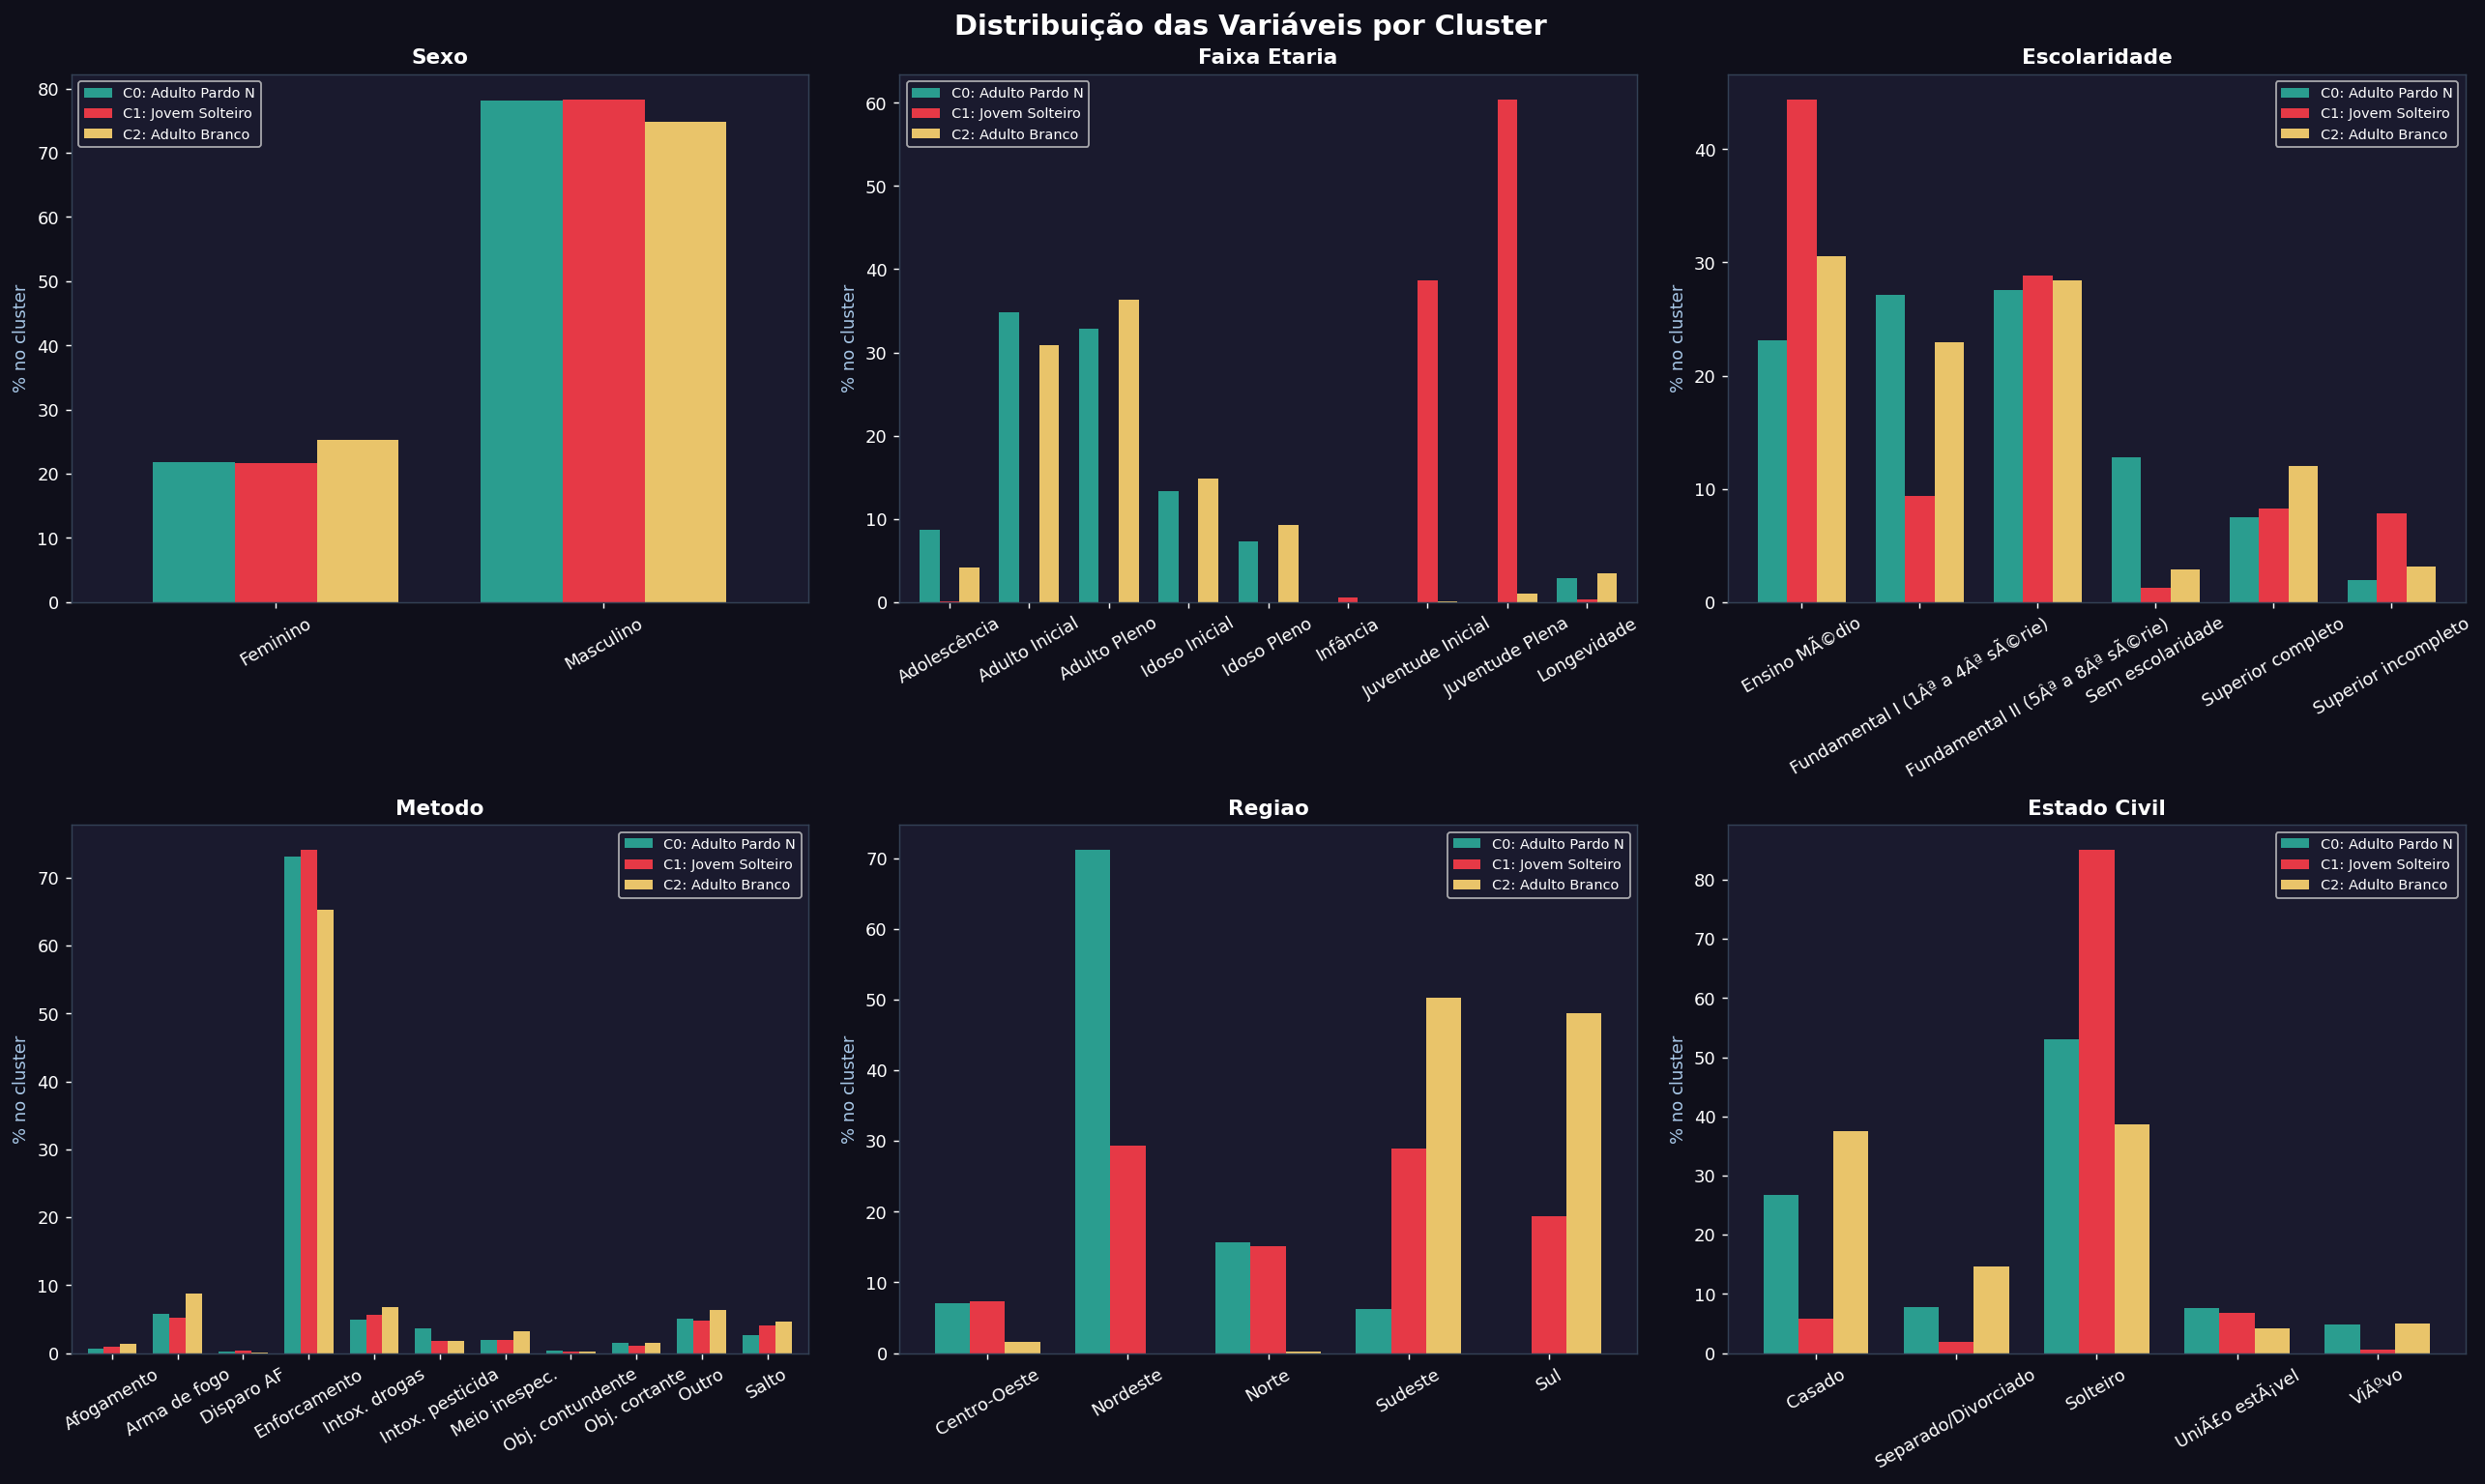

In [1]:
# Distribuição das variáveis por cluster

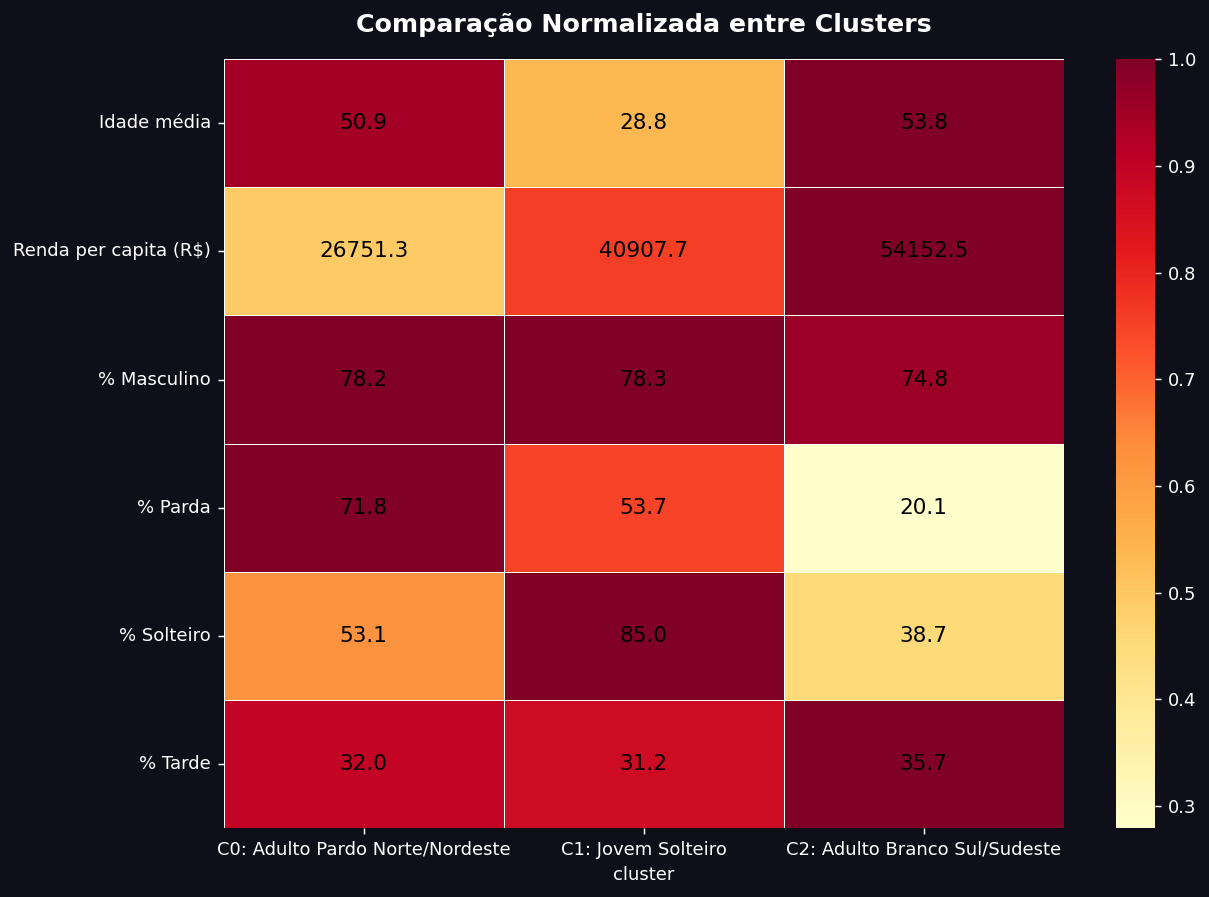

In [1]:
# Heatmap comparativo entre clusters

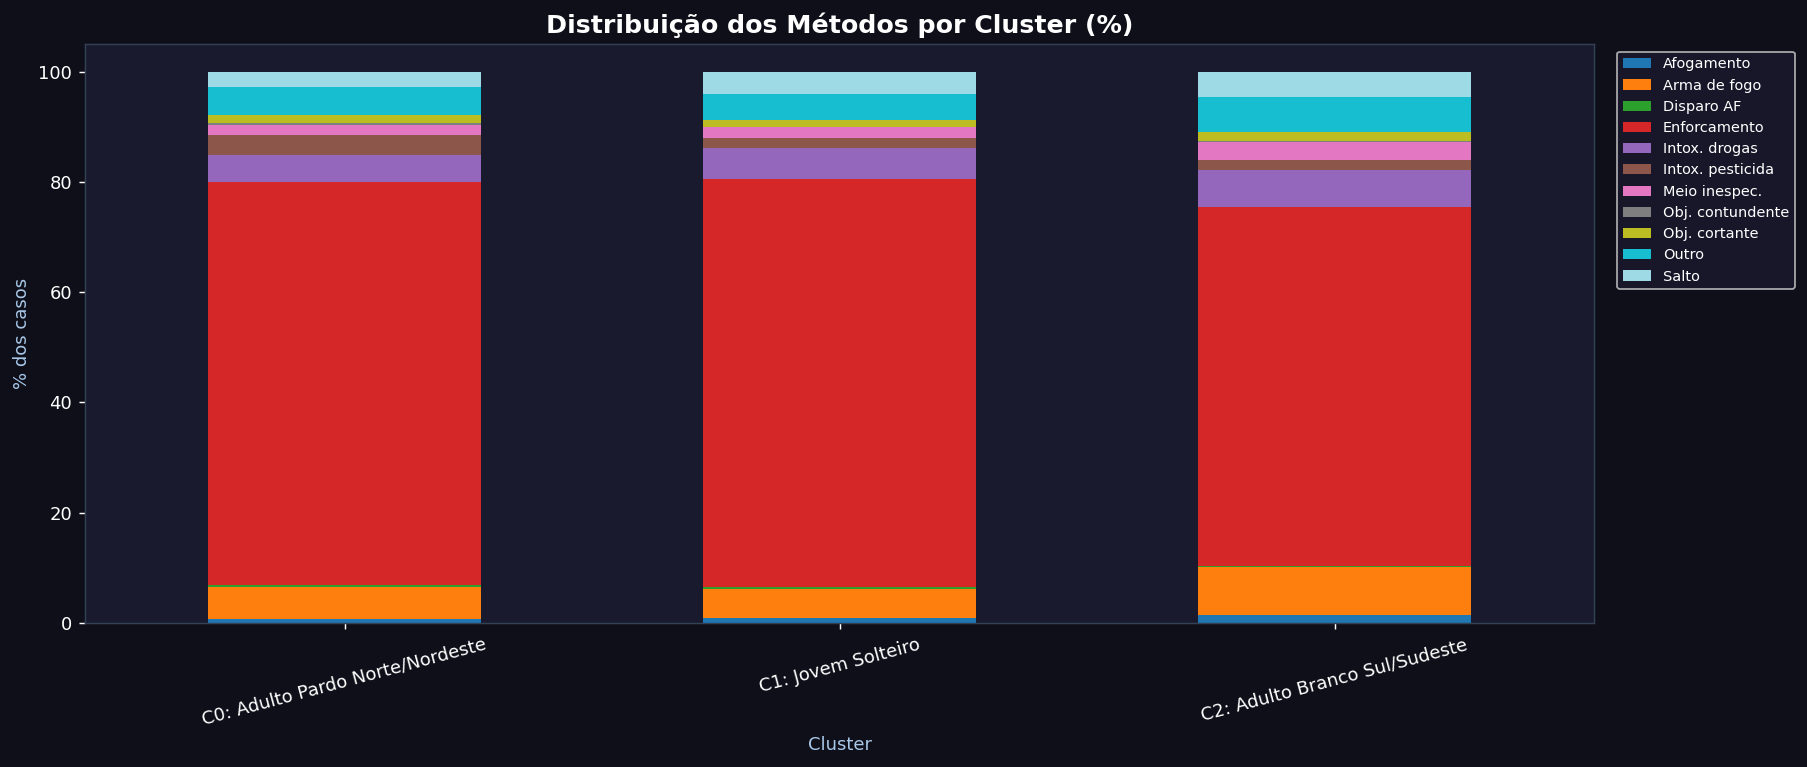

In [1]:
# Distribuição de métodos por cluster (stacked)

<a id="9"></a>
## 9. Perfilamento dos Clusters

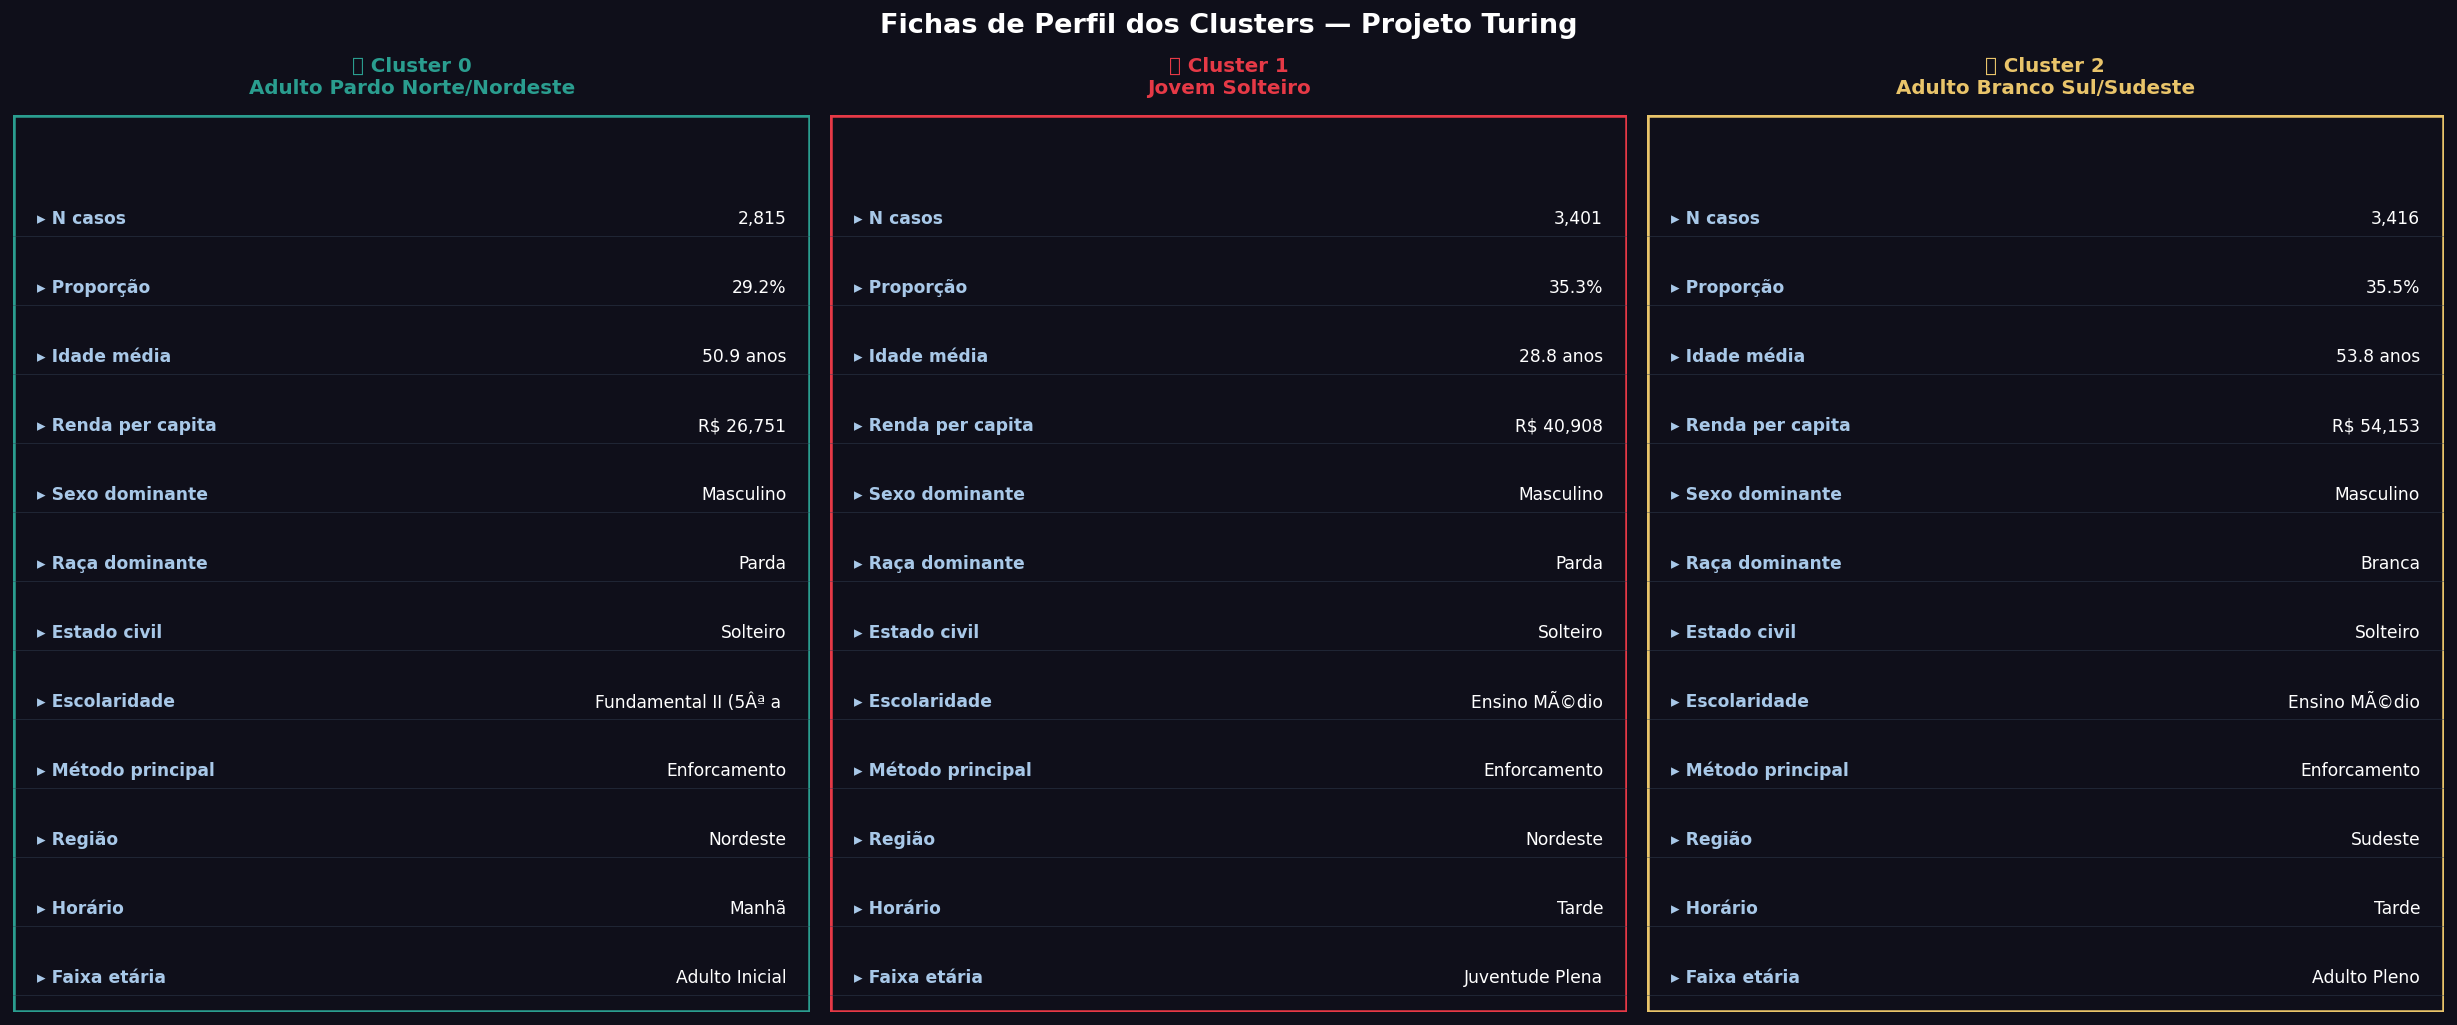

In [1]:
# Fichas de perfil dos 3 clusters

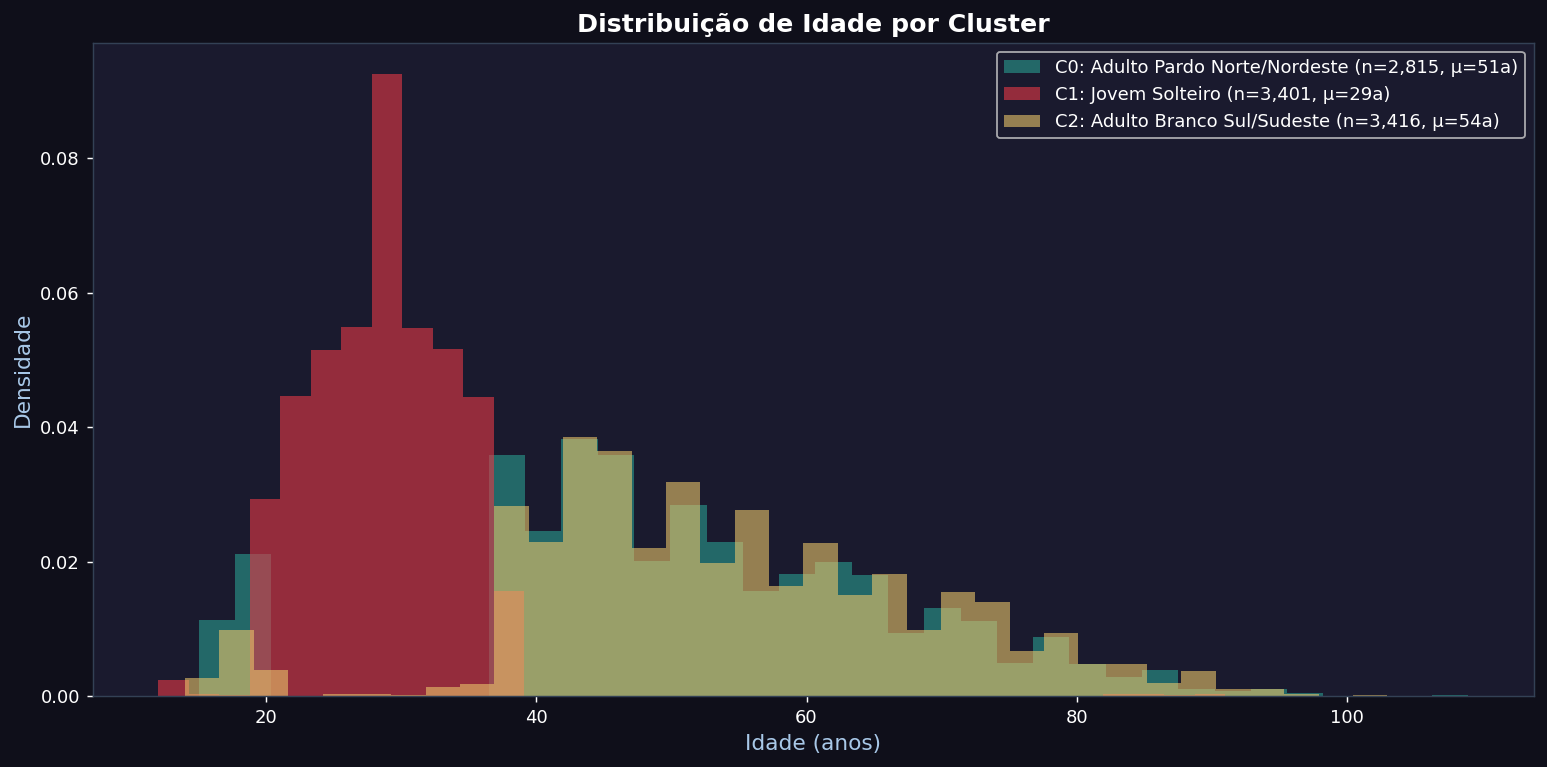

In [1]:
# Distribuição de idade por cluster

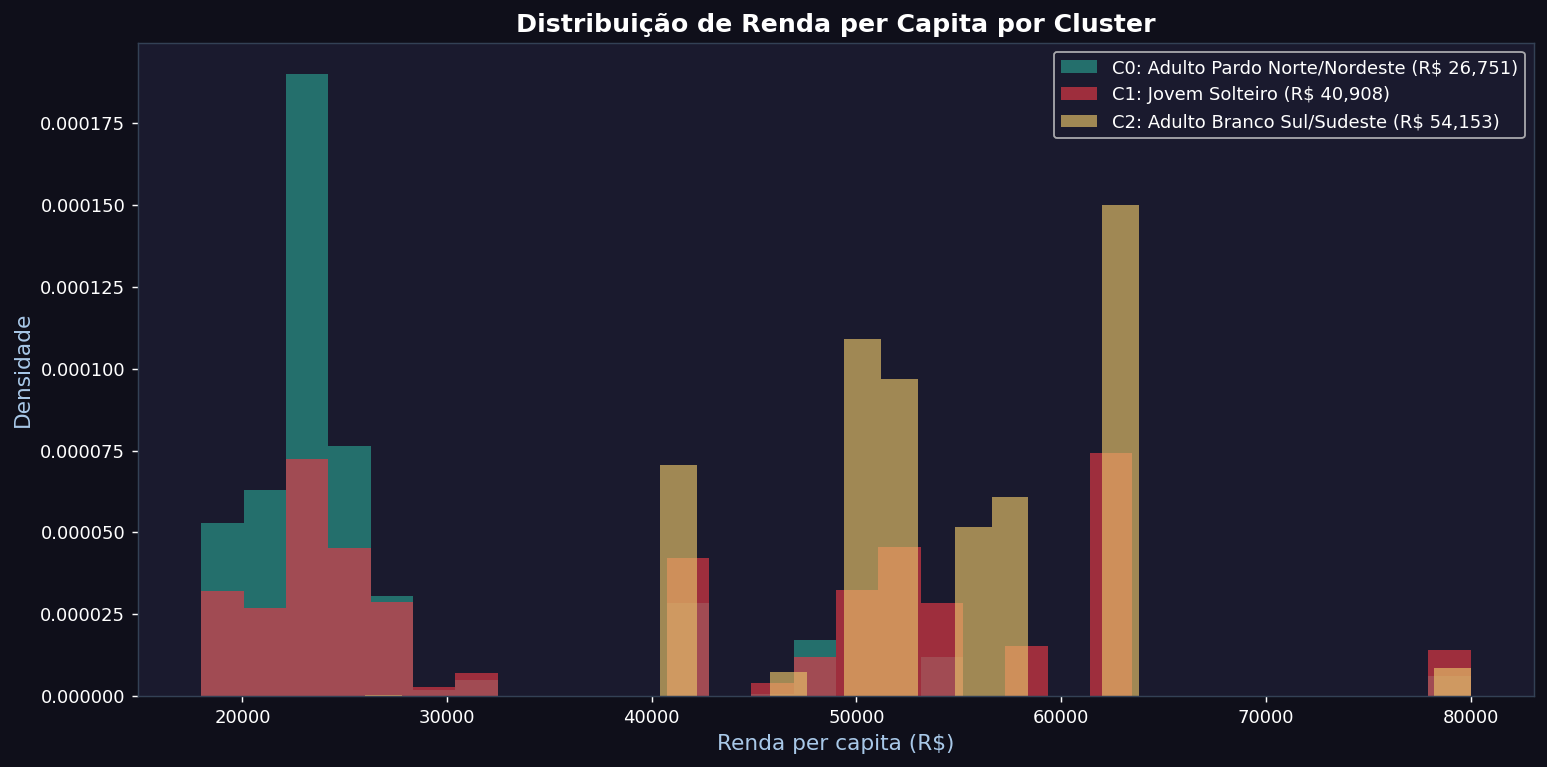

In [1]:
# Distribuição de renda per capita por cluster

In [1]:
# Resumo estatístico por cluster
NOMES = {0:'Adulto Pardo Norte/Nordeste', 1:'Jovem Solteiro', 2:'Adulto Branco Sul/Sudeste'}
for c_id in range(3):
    sub = df_cl[df_cl['cluster']==c_id]
    print(f"{'='*55}")
    print(f"  Cluster {c_id} — {NOMES[c_id]}")
    print(f"  n={len(sub):,} ({100*len(sub)/len(df_cl):.1f}%)")
    print(f"{'='*55}")
    print(f"  Idade média       : {sub['idade'].mean():.1f} anos (dp: {sub['idade'].std():.1f})")
    print(f"  Renda per capita  : R$ {sub['renda_pc'].mean():,.0f}")
    print(f"  Sexo              : {sub['sexo'].mode()[0]} ({100*(sub['sexo']==sub['sexo'].mode()[0]).mean():.1f}%)")
    print(f"  Raça/Cor          : {sub['raca'].mode()[0]} ({100*(sub['raca']==sub['raca'].mode()[0]).mean():.1f}%)")
    print(f"  Estado civil      : {sub['estado_civil'].mode()[0]}")
    print(f"  Escolaridade      : {sub['escolaridade'].mode()[0]}")
    print(f"  Método principal  : {sub['metodo'].mode()[0]}")
    print(f"  Região            : {sub['regiao'].mode()[0]}")
    print(f"  Horário           : {sub['faixa_horaria'].mode()[0]}")
    print(f"  Faixa etária      : {sub['faixa_etaria'].mode()[0]}")
    print()

  Cluster 0 — Adulto Pardo Norte/Nordeste
  n=2.815 (29.2%)
  Idade média       : 50.9 anos (dp: 16.3)
  Renda per capita  : R$ 26.751
  Sexo              : Masculino (82.8%)
  Raça/Cor          : Parda (77.3%)
  Estado civil      : Solteiro
  Escolaridade      : Fundamental I (1ª a 4ª série)
  Método principal  : Enforcamento
  Região            : Nordeste
  Horário           : Manhã
  Faixa etária      : Adulto Pleno

  Cluster 1 — Jovem Solteiro
  n=3.401 (35.3%)
  Idade média       : 28.8 anos (dp: 8.1)
  Renda per capita  : R$ 40.908
  Sexo              : Masculino (79.2%)
  Raça/Cor          : Parda (71.1%)
  Estado civil      : Solteiro
  Escolaridade      : Ensino Médio
  Método principal  : Enforcamento
  Região            : Nordeste
  Horário           : Tarde
  Faixa etária      : Juventude Plena

  Cluster 2 — Adulto Branco Sul/Sudeste
  n=3.416 (35.5%)
  Idade média       : 53.8 anos (dp: 16.7)
  Renda per capita  : R$ 54.153
  Sexo              : Masculino (74.2%)
  Raça/

<a id="10"></a>
## 10. Insights para Prevenção — Projeto Turing


---

## 🟢 Cluster 0 — "Adulto Pardo Norte/Nordeste" (29,2% | 2.815 casos)

| Variável | Perfil |
|---|---|
| Sexo | Masculino (82,8%) |
| Raça/Cor | **Parda** (77,3%) |
| Faixa etária | Adulto Pleno (45–59 anos) |
| Escolaridade | **Fundamental I** (menor escolaridade dos clusters) |
| Estado civil | Solteiro |
| Método | Enforcamento (dominante) |
| Região | **Nordeste e Norte** |
| Renda per capita | **R$ 26.751** (a mais baixa) |
| Horário | Manhã |

### 🧩 Interpretação
Evidencia a **intersecção entre pobreza estrutural, baixa escolaridade e risco suicida**. Homens pardos, de meia-idade, vivendo nas regiões com menor IDH e menor cobertura de serviços de saúde mental. O isolamento geográfico, a falta de CAPS e a subnotificação amplificam o problema real.

### 🎯 Ações prioritárias para o Projeto Turing
- **ACS (Agentes Comunitários de Saúde)**: capacitação para rastreio ativo nas UBS do Norte e Nordeste
- **CAPS**: expansão e redução de filas nessas regiões
- **Materiais preventivos**: linguagem acessível, baixa escolaridade
- **CVV regional**: reforço de plantões no período matutino nessas regiões

---

## 🔴 Cluster 1 — "Jovem Solteiro" (35,3% | 3.401 casos)

| Variável | Perfil |
|---|---|
| Sexo | Masculino (79,2%) |
| Raça/Cor | Parda (71,1%) |
| Faixa etária | **Juventude Plena (15–29 anos)** |
| Escolaridade | Ensino Médio |
| Estado civil | **Solteiro** (91,3%) |
| Método | Enforcamento + Intoxicação |
| Região | Nordeste / Sudeste / Norte |
| Renda per capita | R$ 40.908 |
| Horário | Tarde |

### 🧩 Interpretação
O cluster de **maior urgência em termos de anos de vida perdidos** (DALY). Jovens solteiros, sem vínculos afetivos estáveis, com alta exposição digital e baixa propensão a buscar ajuda presencial. O horário vespertino e o perfil jovem sugerem maior componente impulsivo no ato.

### 🎯 Ações prioritárias para o Projeto Turing
- **CVV digital**: chat, WhatsApp e redes sociais — o jovem não liga, digita
- **Escolas/universidades**: programas de saúde mental e triagem precoce
- **Algoritmos de risco**: este cluster deve ter peso elevado no modelo preditivo do SUS
- **Intervenção de crise em tempo real**: a janela de oportunidade vespertina é crítica

---

## 🟡 Cluster 2 — "Adulto Branco Sul/Sudeste" (35,5% | 3.416 casos)

| Variável | Perfil |
|---|---|
| Sexo | Masculino (74,2%) |
| Raça/Cor | **Branca** (84,5%) |
| Faixa etária | Adulto Pleno (45–59 anos) + Idoso |
| Escolaridade | Ensino Médio |
| Estado civil | Solteiro / Separado |
| Método | Enforcamento + **Arma de fogo** (2º maior) |
| Região | **Sul e Sudeste** |
| Renda per capita | **R$ 54.153** (a mais alta) |
| Horário | Tarde |

### 🧩 Interpretação
Desmonta o mito de que pobreza é o único fator de risco. Homens brancos, de maior renda, com acesso a meios letais (armas de fogo legalizada no Sul/Sudeste). O isolamento masculino após separação, o estigma cultural em buscar ajuda e a letalidade maior dos métodos disponíveis configuram risco de alta lethality.

### 🎯 Ações prioritárias para o Projeto Turing
- **SUS**: rastreio ativo de ideação em homens 45–60 anos nas consultas de rotina
- **Restrição de meios**: políticas de guarda segura de armas de fogo
- **Campanhas de masculinidade**: comunicação que quebre o estigma de pedir ajuda
- **CVV**: treinamento específico para atendimento de homens de meia-idade

---

## 📊 Síntese para o Modelo Preditivo do Projeto Turing

| Feature | Importância para o modelo |
|---|---|
| Sexo masculino | ⭐⭐⭐ Alta — transversal a todos os clusters |
| Faixa etária (15–29 e 45–60) | ⭐⭐⭐ Alta — picos de risco nos extremos |
| Estado civil solteiro/separado | ⭐⭐ Média-alta — indicador de isolamento |
| Baixa escolaridade | ⭐⭐ Média-alta — cluster 0 crítico |
| Região Norte/Nordeste | ⭐⭐ Média — menor acesso a cuidados |
| Renda per capita | ⭐⭐ Média — bidirecional (pobreza e isolamento rico) |
| Horário vespertino/matutino | ⭐ Média — janela de intervenção ativa |

> *"A tecnologia a serviço da vida — cada cluster é uma política pública que ainda não existia."*
> — **Projeto Turing**


In [1]:
# Exportar dataset com clusters para pipeline do Projeto Turing
df_cl.to_csv('perfis_suicidio_clustered_projeto_turing.csv', index=False, encoding='utf-8-sig')
print("✅ Dataset exportado: perfis_suicidio_clustered_projeto_turing.csv")
print(f"   {len(df_cl):,} registros | 3 clusters | pronto para uso no modelo preditivo")

✅ Dataset exportado: perfis_suicidio_clustered_projeto_turing.csv
   9.632 registros | 3 clusters | pronto para uso no modelo preditivo
